# Hospital Count Mapping with 3 GIS Agents from 2 Distributed GAS Servers using 3 Request Modes

This notebook demonstrates a compact GAS service chain using agents hosted on two distributed GAS servers:

- GAS Server 1: `https://www.geospatial-agentic-services.online`
- GAS Server 2: `https://suspect-maroon-snowy.ngrok-free.dev`

The workflow first invokes the PASDA Agent from GAS Server 1 in **synchronous** mode to download Pennsylvania county boundaries and hospital locations. It then passes the returned dataset URLs to the Vector Analysis Agent from GAS Server 2, where the task is submitted in **asynchronous** mode. The client polls the task status every two seconds and retrieves the result when the task finishes. Finally, the Mapping Agent from GAS Server 1 uses **streaming** mode to create a county-level choropleth map of hospital counts.

This example follows the GAS service-consumer pattern. Each agent is called as an independent web service, and the client passes returned artifact URLs from one service to the next. The workflow shows how GAS clients can compose geospatial agents across distributed servers while preserving a clear and reproducible execution chain.

In [5]:
!pip install gas-client

In [6]:
from pathlib import Path
from urllib.parse import urljoin, urlparse
import time

import requests
from IPython.display import HTML, Image, display

from gas_client import GasClient


## User Settings

Update `server_url` and the API keys for your GAS deployment. The built-in model-backed agents accept either an OpenAI API key or a GIBD API key, depending on how the server host has configured the agents.

In [7]:
gas_server1 = "https://www.geospatial-agentic-services.online/"  # GAS server 1
gas_server2 = "https://suspect-maroon-snowy.ngrok-free.dev"   # GAS server 2
openai_api_key = "your openai api key"

poll_timeout = 2400


## Helpers

In [8]:
project_root = Path.cwd()
if project_root.name == "examples_for_using_gas_services":
    project_root = project_root.parent

def first_artifact_url(task_result, preferred_extensions=None):
    """Return the first artifact URL, prioritizing selected file extensions."""

    artifacts = task_result.get("outputs", {}).get("artifacts", [])
    preferred_extensions = preferred_extensions or []

    for extension in preferred_extensions:
        for artifact in artifacts:
            url = artifact.get("url")
            filename = artifact.get("filename") or artifact.get("name") or url or ""
            if url and str(filename).lower().endswith(extension.lower()):
                return url

    for artifact in artifacts:
        if artifact.get("url"):
            return artifact["url"]

    raise RuntimeError("The task returned no artifact URL.")


def absolute_url(url):
    """Resolve relative artifact URLs against the configured GAS server URL."""

    if url.startswith("/"):
        return urljoin(gas_server1, url)
    return url


def artifact_display_name(artifact):
    return artifact.get("filename") or artifact.get("name") or "artifact"


def local_artifact_path(artifact, url):
    cache_dir = project_root / "examples_for_using_gas_services" / "downloaded_gas_artifacts"
    cache_dir.mkdir(parents=True, exist_ok=True)

    filename = artifact_display_name(artifact)
    if not Path(filename).suffix:
        filename = Path(urlparse(url).path).name or "gas_artifact"
    return cache_dir / filename


def download_artifact(artifact):
    url = absolute_url(artifact.get("url"))
    path = local_artifact_path(artifact, url)

    if not path.exists():
        response = requests.get(url, timeout=300)
        response.raise_for_status()
        path.write_bytes(response.content)

    return path


def display_task_artifacts(task_result, max_vector_rows=5):
    """Display common GAS artifacts inline when possible."""

    artifacts = task_result.get("outputs", {}).get("artifacts", [])
    if not artifacts:
        print("No artifacts to display.")
        return

    for artifact in artifacts:
        url = artifact.get("url")
        if not url:
            continue

        name = artifact_display_name(artifact)
        suffix = Path(name).suffix.lower() or Path(urlparse(url).path).suffix.lower()
        print(f"Artifact: {name}")

        try:
            path = download_artifact(artifact)

            if suffix in {".geojson", ".json", ".gpkg", ".shp"}:
                import geopandas as gpd
                import matplotlib.pyplot as plt

                gdf = gpd.read_file(path)
                ax = gdf.plot(figsize=(10, 6), edgecolor="black", linewidth=0.3, alpha=0.8)
                ax.set_axis_off()
                display(plt.gcf())
                plt.close()
                display(gdf.head(max_vector_rows))
            elif suffix == ".csv":
                import pandas as pd

                display(pd.read_csv(path).head(max_vector_rows))
            elif suffix in {".png", ".jpg", ".jpeg", ".gif"}:
                display(Image(filename=str(path)))
            elif suffix in {".html", ".htm"}:
                html = path.read_text(encoding="utf-8", errors="ignore")
                display(HTML(f'<iframe srcdoc={html!r} width="100%" height="720" style="border:1px solid #ddd;"></iframe>'))
            else:
                display(HTML(f'<a href="{absolute_url(url)}" target="_blank">Open or download artifact</a>'))
        except Exception as exc:
            print(f"Could not render this artifact inline: {exc}")
            display(HTML(f'<a href="{absolute_url(url)}" target="_blank">Open or download artifact</a>'))


## Create Client and Agent Handles

In [9]:
gas1 = GasClient(
    gas_server1,
    default_credentials={"OPENAI_API_KEY": openai_api_key},
)

gas2 = GasClient(
    gas_server2,
    default_credentials={"OPENAI_API_KEY": openai_api_key},
)

pasda_agent = gas1.agent("pasda_agent")
vector_agent = gas2.agent("vector_analysis_agent")
mapping_agent = gas1.agent("mapping_agent")


## 1. PASDA Agent: Download Pennsylvania County Boundaries (Synchronous Mode)

In synchronous mode, `ExecuteTask` returns the final task result directly after the server finishes the work.


In [10]:
county_boundaries_task = pasda_agent.execute_task(
    instructions="Download Pennsylvania county boundaries. Include county names and county identifiers if available.",
    mode="sync",
    artifact_delivery="URL",
    timeout=poll_timeout,
)

gas1.print_task_summary(county_boundaries_task)
county_boundaries_url = first_artifact_url(county_boundaries_task)
county_boundaries_url



GAS Task Summary
Task         : cc0a637f-b01a-49b0-b721-cdc65671e386
Status       : successful
Agent        : PASDA Discovery Agent
Version      : 1.0.0
Model        : gpt-4o
Duration     : 16.16s
Iterations   : 9

Usage
-----
LLM calls    : 9
Tool calls   : 9
Input tokens : 12,668
Output tokens: 325
Total tokens : 12,993

Outputs
-------
Summary      : This dataset represents the county boundaries within Pennsylvania as delineated for the PennDOT Type 10 general highway map. The data is projected in the EPSG:4269 coordinate reference system and features polygon geometries. It provides a detailed and accurate representation of county boundaries, which is essential for transportation planning and management. The dataset is particularly relevant for the year 2026, reflecting the most current administrative boundaries as recognized by the Pennsylvania Department of Transportation.
Artifacts    : 1
  1. pasda_agent-2869-qyyk-8686.gpkg
     type=downloadable_file format=gpkg size=2,617,344

'https://www.geospatial-agentic-services.online/agents/pasda_agent/data/pasda_agent-2869-qyyk-8686.gpkg'

Artifact: pasda_agent-2869-qyyk-8686.gpkg


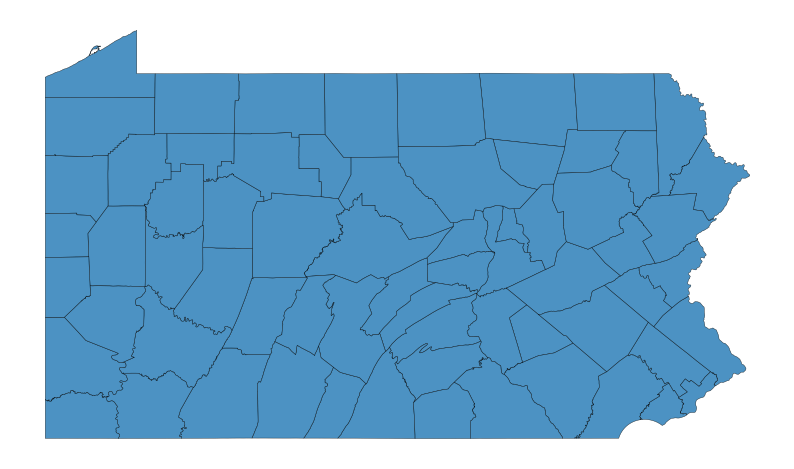

,OBJECTID,COUNTY_NAM,FIPS_COUNT,DISTRICT_N,Shape_Length,Shape_Area,MSLINK,COUNTY_NUM,COUNTY_ARE,COUNTY_PER,...,PA_CTY_COD,MAINT_CTY_,DISTRICT_O,GIS_UPDATE,GIS_GEOMET,GPID,Shape_Leng,AREA,LEN,geometry
0,1,MONTGOMERY,091,06,258604.890065,2.166141e+09,46,46,0,0,...,46,4,6-4,None,None,2079,258604.890065,0,0,"MULTIPOLYGON (((-75.44846 40.09112, -75.44208 ..."
1,2,BRADFORD,015,03,298321.648632,5.413086e+09,8,08,0,0,...,08,9,3-9,None,None,2080,298321.648632,0,0,"MULTIPOLYGON (((-76.88351 41.66631, -76.88127 ..."
2,3,BUCKS,017,06,267969.259703,2.774727e+09,9,09,0,0,...,09,1,6-1,None,None,2081,267969.259703,0,0,"MULTIPOLYGON (((-75.16528 40.56436, -75.16556 ..."
3,4,TIOGA,117,03,291163.817946,5.299046e+09,58,58,0,0,...,59,7,3-7,None,None,2082,291163.817946,0,0,"MULTIPOLYGON (((-76.88351 41.66631, -76.88385 ..."
4,5,UNION,119,03,196854.554335,1.445163e+09,59,59,0,0,...,60,8,3-8,None,None,2083,196854.554335,0,0,"MULTIPOLYGON (((-76.92152 40.88579, -76.92043 ..."


In [11]:
display_task_artifacts(county_boundaries_task)

## 2. PASDA Agent: Download Pennsylvania Hospital Locations (Synchronous Mode)

This second PASDA request also uses synchronous mode so the notebook receives the completed hospital point dataset directly.


In [12]:
hospital_locations_task = pasda_agent.execute_task(
    instructions="Download Pennsylvania hospital locations as a point dataset. Include hospital name, address, county, and any available identifiers.",
    mode="sync",
    artifact_delivery="URL",
    timeout=poll_timeout,
)

gas1.print_task_summary(hospital_locations_task)
hospital_locations_url = first_artifact_url(hospital_locations_task)
hospital_locations_url



GAS Task Summary
Task         : 1cc6fe58-db7a-4db3-901d-eaa0134aed30
Status       : successful
Agent        : PASDA Discovery Agent
Version      : 1.0.0
Model        : gpt-4o
Duration     : 1.85s
Iterations   : 1

Usage
-----
LLM calls    : 1
Tool calls   : 0
Input tokens : 1,449
Output tokens: 151
Total tokens : 1,600

Outputs
-------
Summary      : This dataset contains the geographic coordinates of 247 hospitals located in Pennsylvania, with efforts made to confirm the rooftop location of each hospital. The data is recorded in the WGS 1984 coordinate system (EPSG:4326) and includes attributes such as survey ID number, facility name, longitude, latitude, and geocoding certainty. The information was obtained from an annual hospital survey and was last updated on February 1, 2016. This dataset is useful for analyzing the spatial distribution of hospitals across Pennsylvania and can be linked to additional data fields for more comprehensive analysis.
Artifacts    : 1
  1. pasda_agent-3

'https://www.geospatial-agentic-services.online/agents/pasda_agent/data/pasda_agent-3019-foyd-5874.gpkg'

Artifact: pasda_agent-3019-foyd-5874.gpkg


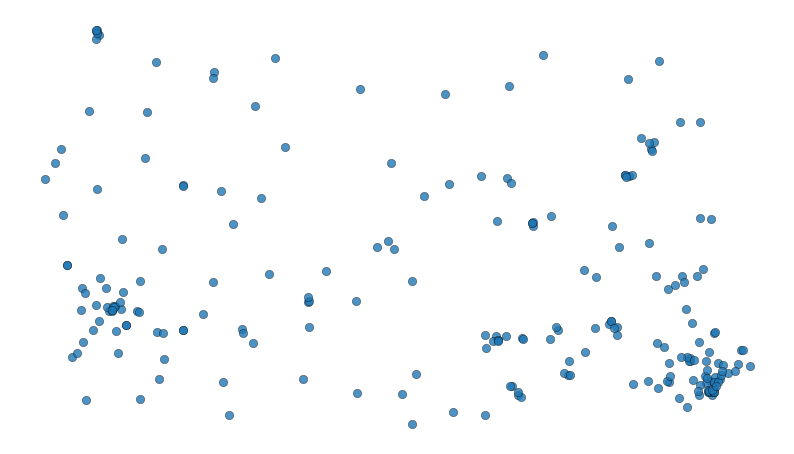

,LONGITUDE,LATITUDE,STREET,COUNTY,ZIP_CODE,OBJECTID,ID_NUMBER,WEBSITE,CERTAINTY,NAME,CITY,TELEPHONE,EXEC_NAME,EXEC_TITLE,geometry
0,-80.190773,40.245850,100 Medical Boulevard,Washington,15317,1,29530100,http://www.ahn.org,00,Canonsburg Hospital,Canonsburg,724-745-6100,Chong Park,None,POINT (-80.19077 40.24585)
1,-79.093108,41.156519,100 Hospital Road,Jefferson,15825,2,28050101,http://www.phhealthcare.org,00,Penn Highlands Brookville,Brookville,814-849-2312,Julianne Peer,None,POINT (-79.09311 41.15652)
2,-75.670913,40.844793,500 St. Luke's Drive,Carbon,18235,3,26080101,https://www.slhn.org,00,St. Luke's Hospital Carbon Campus,Lehighton,484-464-9000,John Nespoli,None,POINT (-75.67091 40.84479)
3,-75.972999,40.372842,201 Wellness Way,Berks,19605,4,24940101,https://www.towerbehavioralhealth.com,00,Tower Behavioral Health,Reading,484-659-2330,Jenna Pacini,None,POINT (-75.973 40.37284)
4,-76.092002,40.641540,100 Paramount Blvd,Schuylkill,17961,5,24870101,https://www.slhn.org,00,Geisinger St. Luke's,Orwigsburg,272-639-4990,Gabe Kamarousky,None,POINT (-76.092 40.64154)


In [13]:
display_task_artifacts(hospital_locations_task)

## 3. Vector Analysis Agent: Count Hospitals in Each County (Asynchronous Task Mode)

The Vector Analysis Agent receives the county polygon dataset and hospital point dataset returned by the PASDA Agent. It performs a point-in-polygon spatial join and returns a county polygon dataset with a hospital count field.

This step uses asynchronous task mode. The first request returns a `task_id`; the notebook then calls `GetTaskStatus` every two seconds and finally calls `GetTaskResult` when the task reaches a terminal status.


In [16]:
hospital_count_task = vector_agent.execute_task(
    instructions="Count the number of hospital points in each Pennsylvania county.",
    mode="async",
    input_datasets=[county_boundaries_url, hospital_locations_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
)

hospital_count_task_id = gas1.get_task_id(hospital_count_task)
print(f"Submitted vector analysis task: {hospital_count_task_id}")

while True:
    status_response = vector_agent.get_task_status(hospital_count_task_id)
    status = gas2.get_task_status_value(status_response)
    print(f"Task status: {status}")

    if status in gas2.TERMINAL_STATUSES:
        break

    time.sleep(2)

hospital_count_task = vector_agent.get_task_result(hospital_count_task_id)
gas2.print_task_summary(hospital_count_task)

if gas2.get_task_status_value(hospital_count_task) != "successful":
    raise RuntimeError("Vector analysis task did not finish successfully.")

hospital_count_url = first_artifact_url(hospital_count_task)
hospital_count_url


Submitted vector analysis task: 822f6821-a7b6-46b7-a3ad-3b8304ae9283
Task status: running
Task status: successful

GAS Task Summary
Task         : 822f6821-a7b6-46b7-a3ad-3b8304ae9283
Status       : successful
Agent        : Vector Analysis Agent
Version      : 2.1.0
Model        : deterministic
Duration     : 0.31s
Iterations   : 0

Usage
-----
LLM calls    : 0
Tool calls   : 0
Input tokens : 0
Output tokens: 0
Total tokens : 0

Outputs
-------
Summary      : Counted 226 point feature(s) within 67 polygon feature(s) and saved the county-level result as GeoPackage with a hospital_count field.
Artifacts    : 1
  1. vector_analysis_agent-5944-cmvk-6656.gpkg
     type=downloadable_file format=gpkg size=2,617,344 bytes
     url=http://suspect-maroon-snowy.ngrok-free.dev/agents/vector_analysis_agent/data/vector_analysis_agent-5944-cmvk-6656.gpkg

Diagnostics
-----------
Has error    : 0
Warnings     : -


'http://suspect-maroon-snowy.ngrok-free.dev/agents/vector_analysis_agent/data/vector_analysis_agent-5944-cmvk-6656.gpkg'

Artifact: vector_analysis_agent-5944-cmvk-6656.gpkg


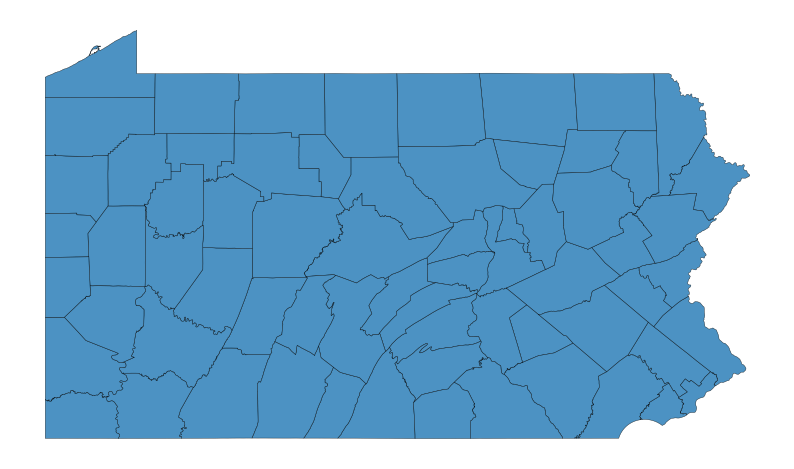

,OBJECTID,COUNTY_NAM,FIPS_COUNT,DISTRICT_N,Shape_Length,Shape_Area,MSLINK,COUNTY_NUM,COUNTY_ARE,COUNTY_PER,...,MAINT_CTY_,DISTRICT_O,GIS_UPDATE,GIS_GEOMET,GPID,Shape_Leng,AREA,LEN,hospital_count,geometry
0,1,MONTGOMERY,091,06,258604.890065,2.166141e+09,46,46,0,0,...,4,6-4,None,None,2079,258604.890065,0,0,15,"MULTIPOLYGON (((-75.44846 40.09112, -75.44208 ..."
1,2,BRADFORD,015,03,298321.648632,5.413086e+09,8,08,0,0,...,9,3-9,None,None,2080,298321.648632,0,0,2,"MULTIPOLYGON (((-76.88351 41.66631, -76.88127 ..."
2,3,BUCKS,017,06,267969.259703,2.774727e+09,9,09,0,0,...,1,6-1,None,None,2081,267969.259703,0,0,8,"MULTIPOLYGON (((-75.16528 40.56436, -75.16556 ..."
3,4,TIOGA,117,03,291163.817946,5.299046e+09,58,58,0,0,...,7,3-7,None,None,2082,291163.817946,0,0,1,"MULTIPOLYGON (((-76.88351 41.66631, -76.88385 ..."
4,5,UNION,119,03,196854.554335,1.445163e+09,59,59,0,0,...,8,3-8,None,None,2083,196854.554335,0,0,1,"MULTIPOLYGON (((-76.92152 40.88579, -76.92043 ..."


In [22]:
display_task_artifacts(hospital_count_task)

## 4. Mapping Agent: Create a Choropleth Map of Hospital Counts (Streaming Mode)

The Mapping Agent uses the county-level hospital count dataset to create the final choropleth map. This step uses streaming mode so progress messages are shown while the map is being generated. This corresponds to the Figure 5C-style output described in the manuscript workflow.


In [19]:
choropleth_map_task = None
for event in mapping_agent.execute_task(
    instructions= (
            "Create a polished county-level choropleth map of Pennsylvania showing the number of hospitals in each county. "
            "Use a reddish color scheme and apply the Lambert Conformal Conic projection. "
            "Include a clear title and legend, and remove all axes for a clean presentation."
            ),
    mode="stream",
    input_datasets=[hospital_count_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    gas1.print_stream_event(event)
    if event.get("event") == "task_result":
        choropleth_map_task = event.get("payload")

if choropleth_map_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

gas1.print_task_summary(choropleth_map_task)
choropleth_map_url = first_artifact_url(choropleth_map_task)
choropleth_map_url


[21:32:39] stream_connected: Streaming connection established.
[21:32:41] Mapping Agent: I received your request.
[21:32:41] Mapping Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[21:32:41] Mapping Agent: I found the required credentials and can start the model-backed workflow.
[21:32:41] task_accepted: Task accepted. Starting streaming execution.
[21:32:41] Mapping Agent: Next I will run the agent with the prepared inputs.
[21:32:41] Mapping Agent: I will inspect the requested visualization and the 1 dataset reference(s), then choose whether a map or chart is the best way to answer it.
[21:32:41] Mapping Agent: I am drafting visualization code now. This is attempt 1; I will run the code and check whether it creates the requested output correctly.
[21:32:51] Mapping Agent: I am still working. Long LLM calls, code execution, or geospatial file processing can take a little while.
[21:32:54] Mapping 

'https://www.geospatial-agentic-services.online/agents/mapping_agent/data/mapping_agent-3275-bozm-9535.png'

Artifact: mapping_agent-3275-bozm-9535.png


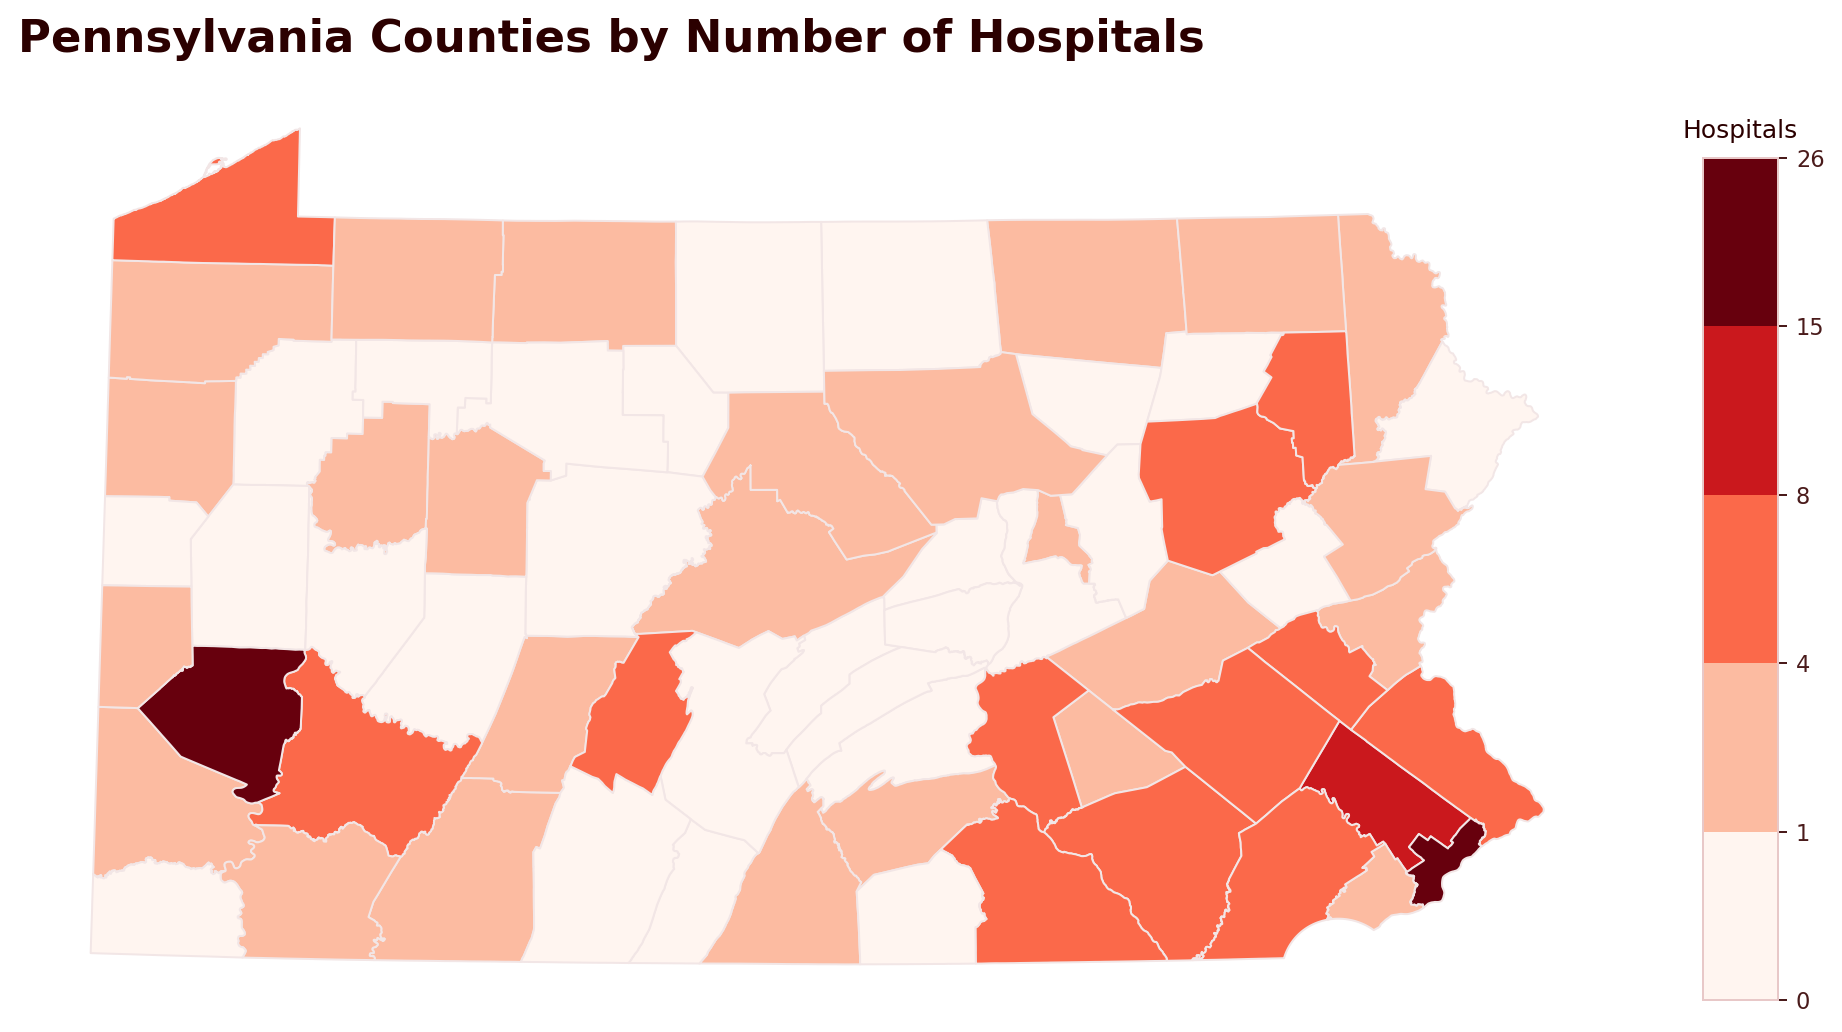

In [20]:
display_task_artifacts(choropleth_map_task)

## Workflow Outputs

At the end of the workflow, the main output is the choropleth map generated by the Mapping Agent. The intermediate artifacts are also useful: the PASDA county boundaries, PASDA hospital point layer, and the county-level hospital count dataset produced by the Vector Analysis Agent.

In [21]:
print("County boundaries:", county_boundaries_url)
print("Hospital locations:", hospital_locations_url)
print("County hospital counts:", hospital_count_url)
print("Choropleth map:", choropleth_map_url)


County boundaries: https://www.geospatial-agentic-services.online/agents/pasda_agent/data/pasda_agent-2869-qyyk-8686.gpkg
Hospital locations: https://www.geospatial-agentic-services.online/agents/pasda_agent/data/pasda_agent-3019-foyd-5874.gpkg
County hospital counts: http://suspect-maroon-snowy.ngrok-free.dev/agents/vector_analysis_agent/data/vector_analysis_agent-5944-cmvk-6656.gpkg
Choropleth map: https://www.geospatial-agentic-services.online/agents/mapping_agent/data/mapping_agent-3275-bozm-9535.png
